# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)
## Ensamble: promedio de XGBoost y LightGBM

Competencia Kaggle: predecir si una reproducción es "abandono temprano" (`ms_played < 30000`). Métrica: ROC-AUC.

**Cuarto notebook post-clases.** El profesor sugirió explícitamente, "para el final", **probar LightGBM y promediar predicciones con XGBoost**. Es el lever grande que queda ahora que las features de comportamiento sueltas entraron en rendimientos decrecientes (el rescate de skip-rates dio +0.0008). La idea del ensamble: dos modelos que cometen **errores distintos** sobre las mismas filas, promediados, se corrigen mutuamente — la ganancia crece cuanto **menos correlacionadas** están sus predicciones, no cuanto mejor es cada uno por separado.

Plan, todo decidido por la CV temporal de siempre:

1. **Base heredada**: el mejor feature set por CV — el del rescate (vecindad + `u_track_skip_rate` suavizado, α=200), AUC CV 0.8586. Las 4 matrices de fold se **precomputan una sola vez** (con la maquinaria de skip-rate: train expanding, validación congelada al borde) para que XGBoost y LightGBM entrenen sobre exactamente los mismos datos.
2. **XGBoost** con la receta de Optuna heredada (sanidad: reproduce 0.8586).
3. **LightGBM** con una búsqueda corta de Optuna (12 trials) — un LGB mal tuneado daría un veredicto de ensamble falsamente pesimista; hay que darle una chance justa.
4. **Diversidad**: correlación entre las predicciones de ambos modelos — el predictor de cuánto puede aportar el promedio.
5. **Peso del blend** `w·XGB + (1−w)·LGB` elegido por CV (barrido de w), con w=1 (XGB solo) y w=0 (LGB solo) como extremos de control.
6. Cierre de siempre: **una única mirada** a `test_interno`, submission con el 100% de train.

Sin re-test de ventana (24 meses ya se validó 7 veces; el blend es sobre modelos, no sobre la ventana de datos). Progreso en **`logs/10_progreso_ensemble.log`** (~40 min; la Optuna de LGB es lo más largo).

## Base heredada (mínima): el mejor feature set por CV (rescate, 0.8586)

Todo el pipeline cerrado: derivadas de la Clase 1, validación temporal de la Clase 2, numéricas de las Clases 3–4, API de la Clase 5, historial de canción, vecindad de bloques y `u_track_skip_rate` suavizado (α=200, prior global) del rescate. Número a reproducir como sanidad de XGBoost: **AUC CV 0.8586**.

In [1]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import xgboost as xgb
import lightgbm as lgb
import optuna

from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "../competition_data"
LOG_ENS = "../logs/10_progreso_ensemble.log"

C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

open(LOG_ENS, "w", encoding="utf-8").close()


def log_progreso(msg):
    linea = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(linea, flush=True)
    with open(LOG_ENS, "a", encoding="utf-8") as flog:
        flog.write(linea + "\n")


optuna.logging.set_verbosity(optuna.logging.WARNING)
log_progreso(f"Ensamble XGB+LGB -- xgboost {xgb.__version__} | lightgbm {lgb.__version__} | optuna {optuna.__version__}")

[17:28:26] Ensamble XGB+LGB -- xgboost 3.2.0 | lightgbm 4.6.0 | optuna 4.9.0


In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode", "user_id",
]
DTYPES = {"spotify_track_uri": "string", "spotify_episode_uri": "string", "audiobook_uri": "string"}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES, low_memory=False)
train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)
train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(), train_raw["spotify_episode_uri"].notna(), train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"], default="desconocido")
ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))
col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(train_raw[col_artista].isin(TOP_ARTISTAS), "otros")
train_raw = train_raw.sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)

n = len(train_raw)
n_train = int(n * 0.85)
df_train = train_raw.iloc[:n_train].copy()
df_test_interno = train_raw.iloc[n_train:].copy()
log_progreso(f"train {len(df_train):,} | test_interno {len(df_test_interno):,} | tasa abandono {train_raw['target'].mean():.4f}")

[17:28:30] train 774,642 | test_interno 136,702 | tasa abandono 0.2780


In [3]:
api = pd.read_pickle(f"{DATA_DIR}/api_features.pkl")
api_idx = api.set_index("uri")


def agregar_columnas_api(df):
    df["uri"] = df["spotify_track_uri"].fillna(df["spotify_episode_uri"])
    df["duracion_ms"] = df["uri"].map(api_idx["duration_ms"])
    df["popularity"] = df["uri"].map(api_idx["popularity"])
    df["explicit_num"] = df["uri"].map(api_idx["explicit"].astype(float))
    df["track_number"] = df["uri"].map(api_idx["track_number"])
    df["album_total_tracks"] = df["uri"].map(api_idx["album_total_tracks"])
    rel = df["uri"].map(api_idx["release_date"]).astype("string")
    rel = rel.where(rel.str.len() != 4, rel + "-01-01")
    rel = rel.where(rel.str.len() != 7, rel + "-01")
    release_dt = pd.to_datetime(rel, errors="coerce", utc=True)
    df["antiguedad_dias"] = (df["ts_dt"] - release_dt).dt.days.astype(float)
    dur = df["duracion_ms"]
    df["dur_menor_30s"] = np.where(dur.isna(), np.nan, (dur < 30000).astype(float))
    df["carga_bucket"] = df["bucket_count_30min"] * dur / (30 * 60 * 1000)
    return df


def agregar_vecindad(df):
    cnt_bloque = df.groupby(["user_id", "ts_dt"]).size()

    def conteo_offset(k):
        idx = pd.MultiIndex.from_arrays([df["user_id"], df["ts_dt"] + pd.Timedelta(minutes=30 * k)])
        return cnt_bloque.reindex(idx).fillna(0).to_numpy()

    df["bucket_prev_count"] = conteo_offset(-1)
    df["bucket_next_count"] = conteo_offset(+1)
    df["plays_2h_antes"] = sum(conteo_offset(-k) for k in (1, 2, 3, 4))
    df["plays_2h_despues"] = sum(conteo_offset(+k) for k in (1, 2, 3, 4))
    return df


full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
full["gap_min"] = (full.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
full["bucket_count_30min"] = full.groupby(["user_id", "ts"])["obs_id"].transform("size")
full["pos_en_bucket"] = full.groupby(["user_id", "ts"]).cumcount()
fecha = full["ts_dt"].dt.floor("D")
full["bucket_count_dia"] = full.groupby(["user_id", fecha])["obs_id"].transform("size")
full["gap_siguiente"] = ((full.groupby("user_id")["ts_dt"].shift(-1) - full["ts_dt"]).dt.total_seconds() / 60.0).fillna(-1)
full = agregar_columnas_api(full)
full["uri_key"] = full["uri"].fillna("sin_uri")
gt = full.groupby(["user_id", "uri_key"], sort=False)
full["u_track_veces"] = gt.cumcount()
full["u_track_recencia"] = (gt["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
full = agregar_vecindad(full)

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]
log_progreso("base heredada lista (numericas + API + historial + vecindad)")

[17:28:38] base heredada lista (numericas + API + historial + vecindad)


In [4]:
TODAS_LAS_FEATURES = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
                      "hora", "dia_semana", "content_type", "artista_top"]
CAT_FINAL = [f for f in TODAS_LAS_FEATURES if f != "hora"] + ["user_id"]
NUM_FINAL = ["gap_min", "bucket_count_30min", "pos_en_bucket", "bucket_count_dia", "gap_siguiente", "hora",
             "duracion_ms", "dur_menor_30s", "carga_bucket", "popularity", "antiguedad_dias",
             "explicit_num", "track_number", "album_total_tracks",
             "u_track_veces", "u_track_recencia",
             "bucket_prev_count", "bucket_next_count", "plays_2h_antes", "plays_2h_despues"]
SKIP_CLAVES, SKIP_BACKOFF, SKIP_ALPHA, SKIP_NAME = ["user_id", "uri_key"], None, 200, "u_track_skip_rate"

RECETA_XGB = dict(max_depth=7, eta=0.030223664895420776, min_child_weight=2,
                  subsample=0.7963585977878456, colsample_bytree=0.79208902443077,
                  gamma=0.8414960952850874)
BASE_PARAMS_XGB = dict(objective="binary:logistic", eval_metric="auc", seed=RANDOM_STATE)
NUM_BOOST_MAX, EARLY_STOP, N_FOLDS = 600, 25, 4
VENTANA = 24
PRIOR = float(df_train["target"].mean())

AUC_RESCATE_CV, AUC_RESCATE_TEST = 0.8586, 0.8612
SCORE_VEC_KAGGLE = 0.86627  # ultimo submit real (vecindad); el rescate no se subio


def make_expanding_folds(df, n_folds=4):
    n = len(df); bordes = np.linspace(0, n, n_folds + 2, dtype=int); folds = []
    for i in range(1, n_folds + 1):
        idx_tr = np.arange(0, bordes[i]); idx_va = np.arange(bordes[i], bordes[i + 1])
        if len(idx_va) > 0 and len(idx_tr) > 0:
            folds.append((idx_tr, idx_va))
    return folds


def filtrar_reciente(df, meses):
    if meses is None:
        return df
    corte = df["ts_dt"].max() - pd.DateOffset(months=int(meses))
    return df[df["ts_dt"] >= corte]


def limpiar_nombres_columnas(cols):
    limpios = [re.sub(r"[\[\]<]", "_", str(c)) for c in cols]
    vistos, out = {}, []
    for c in limpios:
        if c in vistos:
            vistos[c] += 1; out.append(f"{c}__dup{vistos[c]}")
        else:
            vistos[c] = 0; out.append(c)
    return out


def build_sparse_matrix(df, cat_features, num_features):
    cat_features = list(cat_features)
    cat_dummies = pd.get_dummies(df[cat_features], columns=cat_features, dummy_na=True, sparse=True)
    X_cat = sp.csr_matrix(cat_dummies.sparse.to_coo())
    X_num = sp.csr_matrix(df[list(num_features)].astype(float).values)
    X = sp.hstack([X_cat, X_num], format="csr")
    nombres = limpiar_nombres_columnas(list(cat_dummies.columns.astype(str)) + list(num_features))
    return X, df["target"].to_numpy(), nombres


def expanding_smooth(df, claves, alpha, prior):
    g = df.groupby(list(claves), sort=False)["target"]
    n_prev = g.cumcount().to_numpy()
    skips_prev = (g.cumsum() - df["target"]).to_numpy()
    return (skips_prev + alpha * prior) / (n_prev + alpha)


def frozen_smooth(df_hist, df_obj, claves, alpha, prior):
    grp = df_hist.groupby(list(claves))["target"]
    counts, sums = grp.count(), grp.sum()
    if len(claves) == 1:
        nn = df_obj[claves[0]].map(counts).to_numpy(); ss = df_obj[claves[0]].map(sums).to_numpy()
    else:
        idx = pd.MultiIndex.from_frame(df_obj[list(claves)])
        nn = counts.reindex(idx).to_numpy(); ss = sums.reindex(idx).to_numpy()
    nn = np.nan_to_num(nn, nan=0.0); ss = np.nan_to_num(ss, nan=0.0)
    pr = prior if np.isscalar(prior) else np.asarray(prior)
    return (ss + alpha * pr) / (nn + alpha)


print(f"CAT_FINAL ({len(CAT_FINAL)}) | NUM_FINAL ({len(NUM_FINAL)}) + {SKIP_NAME} | PRIOR {PRIOR:.4f}")

CAT_FINAL (9) | NUM_FINAL (20) + u_track_skip_rate | PRIOR 0.2865


### Precómputo de las 4 matrices de fold (una sola vez)

Cada fold arma su matriz con la disciplina del rescate: columna `u_track_skip_rate` **expanding** para las filas de entrenamiento (filtradas a 24 meses) y **congelada al borde del fold** para las de validación. Se guardan `(Xtr, ytr, Xva, yva)` de los 4 folds para que XGBoost, la Optuna de LightGBM y el barrido de peso del ensamble **reutilicen exactamente los mismos datos** — sin recalcular la matriz 40 veces.

In [5]:
X_stat, y_all, nombres_stat = build_sparse_matrix(df_train, CAT_FINAL, NUM_FINAL)
nombres_full = nombres_stat + [SKIP_NAME]
exp_skip = expanding_smooth(df_train, SKIP_CLAVES, SKIP_ALPHA, PRIOR)

FOLDS = []
for idx_tr, idx_val in make_expanding_folds(df_train, N_FOLDS):
    df_hist = df_train.iloc[idx_tr]
    corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=VENTANA)
    idx_f = idx_tr[(df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
    col_tr = exp_skip[idx_f]
    col_va = frozen_smooth(df_hist, df_train.iloc[idx_val], SKIP_CLAVES, SKIP_ALPHA, PRIOR)
    Xtr = sp.hstack([X_stat[idx_f], sp.csr_matrix(col_tr.reshape(-1, 1))], format="csr")
    Xva = sp.hstack([X_stat[idx_val], sp.csr_matrix(col_va.reshape(-1, 1))], format="csr")
    FOLDS.append((Xtr, y_all[idx_f], Xva, y_all[idx_val]))

log_progreso(f"{len(FOLDS)} folds precomputados | train por fold {[f[0].shape[0] for f in FOLDS]} | {FOLDS[0][0].shape[1]} columnas")

[17:28:44] 4 folds precomputados | train por fold [123091, 213635, 243646, 198472] | 156 columnas


### XGBoost sobre los folds precomputados (sanidad: 0.8586)

In [6]:
def xgb_cv(params, folds, guardar_preds=False):
    aucs, rondas, preds = [], [], []
    for Xtr, ytr, Xva, yva in folds:
        dtr = xgb.DMatrix(Xtr, label=ytr, feature_names=nombres_full)
        dva = xgb.DMatrix(Xva, label=yva, feature_names=nombres_full)
        bst = xgb.train({**BASE_PARAMS_XGB, **params}, dtr, num_boost_round=NUM_BOOST_MAX,
                        evals=[(dva, "val")], early_stopping_rounds=EARLY_STOP, verbose_eval=False)
        p = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
        aucs.append(roc_auc_score(yva, p)); rondas.append(bst.best_iteration + 1)
        if guardar_preds:
            preds.append(p)
    return float(np.mean(aucs)), aucs, float(np.mean(rondas)), preds


log_progreso("=== XGBoost (receta heredada) ===")
t0 = time.time()
auc_xgb, aucs_xgb, rondas_xgb, preds_xgb = xgb_cv(RECETA_XGB, FOLDS, guardar_preds=True)
NROUNDS_XGB = int(round(rondas_xgb))
log_progreso(f"XGBoost -> AUC CV {auc_xgb:.4f} | folds {[f'{a:.4f}' for a in aucs_xgb]} | rondas {NROUNDS_XGB} | {time.time()-t0:.0f}s")
log_progreso(f"sanidad: reproduce el 0.8586 del rescate? {auc_xgb:.4f}")

[17:28:44] === XGBoost (receta heredada) ===
[17:30:02] XGBoost -> AUC CV 0.8586 | folds ['0.8085', '0.8557', '0.9061', '0.8639'] | rondas 410 | 78s
[17:30:02] sanidad: reproduce el 0.8586 del rescate? 0.8586


### LightGBM: búsqueda corta de Optuna sobre los mismos folds

LightGBM parametriza la complejidad por **`num_leaves`** (no por profundidad máxima como XGBoost) y tiene sus propios controles de regularización. Para que el ensamble sea justo, se le da una búsqueda corta (12 trials de TPE) en un espacio análogo al que usamos con XGBoost — aprender lento (`learning_rate` bajo, muchas rondas por early stopping), hojas moderadas, subsampleo de filas y columnas, regularización L2. Se encola una configuración sensata como trial 1. El objetivo no es ganarle a XGBoost en solitario, sino tener un segundo modelo **competente y distinto**.

In [7]:
def lgb_cv(params, folds, guardar_preds=False):
    aucs, rondas, preds = [], [], []
    full_params = {"objective": "binary", "metric": "auc", "verbosity": -1, "seed": RANDOM_STATE,
                   "bagging_freq": 1, **params}
    for Xtr, ytr, Xva, yva in folds:
        dtr = lgb.Dataset(Xtr, label=ytr)
        dva = lgb.Dataset(Xva, label=yva, reference=dtr)
        bst = lgb.train(full_params, dtr, num_boost_round=2000, valid_sets=[dva],
                        callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        p = bst.predict(Xva, num_iteration=bst.best_iteration)
        aucs.append(roc_auc_score(yva, p)); rondas.append(bst.best_iteration)
        if guardar_preds:
            preds.append(p)
    return float(np.mean(aucs)), aucs, float(np.mean(rondas)), preds


N_TRIALS_LGB = 12
DEFAULT_LGB = dict(num_leaves=63, learning_rate=0.03, feature_fraction=0.79,
                   bagging_fraction=0.80, min_child_samples=100, lambda_l2=1.0)


def objective_lgb(trial):
    params = {
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255, log=True),
        "learning_rate":     trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300, log=True),
        "lambda_l2":         trial.suggest_float("lambda_l2", 0.0, 5.0),
    }
    auc, _, rondas, _ = lgb_cv(params, FOLDS)
    trial.set_user_attr("rondas", rondas)
    return auc


log_progreso(f"=== LightGBM: Optuna corto ({N_TRIALS_LGB} trials) ===")
study_lgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.enqueue_trial(DEFAULT_LGB)
t0 = time.time()


def log_trial_lgb(study, trial):
    log_progreso(f"[LGB trial {trial.number+1:2d}/{N_TRIALS_LGB}] leaves={trial.params['num_leaves']:3d} "
                 f"lr={trial.params['learning_rate']:.3f} ff={trial.params['feature_fraction']:.2f} "
                 f"bf={trial.params['bagging_fraction']:.2f} -> AUC CV {trial.value:.4f} | mejor {study.best_value:.4f}")


study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_LGB, callbacks=[log_trial_lgb])
log_progreso(f"LightGBM Optuna terminado en {(time.time()-t0)/60:.1f} min")

RECETA_LGB = dict(study_lgb.best_trial.params)
auc_lgb, aucs_lgb, rondas_lgb, preds_lgb = lgb_cv(RECETA_LGB, FOLDS, guardar_preds=True)
NROUNDS_LGB = int(round(rondas_lgb))
log_progreso(f"LightGBM mejor -> AUC CV {auc_lgb:.4f} | folds {[f'{a:.4f}' for a in aucs_lgb]} | rondas {NROUNDS_LGB}")
log_progreso(f"comparacion individual: XGBoost {auc_xgb:.4f} vs. LightGBM {auc_lgb:.4f} ({auc_lgb - auc_xgb:+.4f})")

[17:30:02] === LightGBM: Optuna corto (12 trials) ===
[17:31:02] [LGB trial  1/12] leaves= 63 lr=0.030 ff=0.79 bf=0.80 -> AUC CV 0.8581 | mejor 0.8581
[17:31:19] [LGB trial  2/12] leaves= 42 lr=0.092 ff=0.87 bf=0.84 -> AUC CV 0.8567 | mejor 0.8581
[17:31:49] [LGB trial  3/12] leaves= 17 lr=0.081 ff=0.80 bf=0.88 -> AUC CV 0.8556 | mejor 0.8581
[17:33:05] [LGB trial  4/12] leaves=158 lr=0.028 ff=0.59 bf=0.67 -> AUC CV 0.8591 | mejor 0.8591
[17:34:19] [LGB trial  5/12] leaves= 50 lr=0.032 ff=0.81 bf=0.66 -> AUC CV 0.8583 | mejor 0.8591
[17:34:47] [LGB trial  6/12] leaves= 54 lr=0.071 ff=0.60 bf=0.81 -> AUC CV 0.8579 | mejor 0.8591
[17:35:59] [LGB trial  7/12] leaves= 83 lr=0.026 ff=0.53 bf=0.98 -> AUC CV 0.8589 | mejor 0.8591
[17:37:13] [LGB trial  8/12] leaves= 35 lr=0.023 ff=0.84 bf=0.78 -> AUC CV 0.8573 | mejor 0.8591
[17:37:42] [LGB trial  9/12] leaves= 16 lr=0.086 ff=0.63 bf=0.87 -> AUC CV 0.8561 | mejor 0.8591
[17:39:05] [LGB trial 10/12] leaves= 70 lr=0.027 ff=0.98 bf=0.91 -> AUC C

### Diversidad de los dos modelos

El promedio ayuda en la medida en que los modelos se equivocan en filas distintas. Se mide la correlación (Pearson y Spearman) entre las predicciones de validación de XGBoost y LightGBM, concatenando los 4 folds. Correlación muy alta (>0.99) → los modelos ven casi lo mismo, el blend rinde poco; correlación más baja → hay diversidad que explotar.

[17:42:32] diversidad: correlacion Pearson 0.9902 | Spearman 0.9884 (mas baja = mas margen para el promedio)


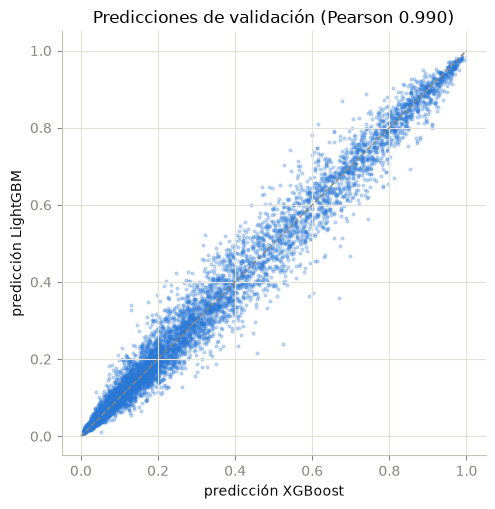

In [8]:
p_xgb_all = np.concatenate(preds_xgb)
p_lgb_all = np.concatenate(preds_lgb)
y_va_all = np.concatenate([yva for _, _, _, yva in FOLDS])

corr_pearson = float(np.corrcoef(p_xgb_all, p_lgb_all)[0, 1])
corr_spearman = float(spearmanr(p_xgb_all, p_lgb_all).statistic)
log_progreso(f"diversidad: correlacion Pearson {corr_pearson:.4f} | Spearman {corr_spearman:.4f} "
             f"(mas baja = mas margen para el promedio)")

fig, ax = plt.subplots(figsize=(5.2, 5.2))
muestra = np.random.default_rng(RANDOM_STATE).choice(len(p_xgb_all), size=min(8000, len(p_xgb_all)), replace=False)
ax.scatter(p_xgb_all[muestra], p_lgb_all[muestra], s=4, alpha=0.25, color=C_AZUL)
ax.plot([0, 1], [0, 1], color=C_MUTED, ls="--", lw=1)
ax.set_xlabel("predicción XGBoost")
ax.set_ylabel("predicción LightGBM")
ax.set_title(f"Predicciones de validación (Pearson {corr_pearson:.3f})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Peso del promedio, elegido por CV

Se barre `w` en `blend = w·XGB + (1−w)·LGB` de 0 a 1, evaluando el AUC CV promedio de los 4 folds en cada `w`. Los extremos son los controles: `w=1` es XGBoost solo (0.8586), `w=0` es LightGBM solo. Si el máximo cae en el interior (0<w<1) y supera a ambos, el ensamble aporta. Como el blend es una operación sobre predicciones ya calculadas, el barrido es instantáneo — no re-entrena nada.

[17:42:37] === Peso del ensamble ===
[17:42:37] w=1.0 (XGB solo) 0.8586 | w=0.0 (LGB solo) 0.8591
[17:42:37] mejor w=0.40 -> AUC CV ensamble 0.8597 (vs. XGB 0.8586 +0.0011 | vs. LGB 0.8591 +0.0006)


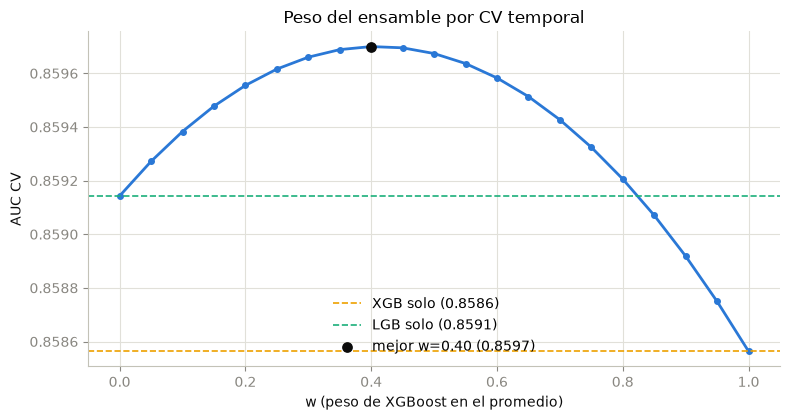

In [9]:
ys_folds = [yva for _, _, _, yva in FOLDS]
ws = np.round(np.linspace(0, 1, 21), 2)


def auc_blend(w):
    fold_aucs = [roc_auc_score(ys_folds[i], w * preds_xgb[i] + (1 - w) * preds_lgb[i]) for i in range(len(FOLDS))]
    return float(np.mean(fold_aucs))


curva_w = [(w, auc_blend(w)) for w in ws]
W_STAR, AUC_ENS = max(curva_w, key=lambda t: t[1])
log_progreso(f"=== Peso del ensamble ===")
log_progreso(f"w=1.0 (XGB solo) {auc_blend(1.0):.4f} | w=0.0 (LGB solo) {auc_blend(0.0):.4f}")
log_progreso(f"mejor w={W_STAR:.2f} -> AUC CV ensamble {AUC_ENS:.4f} "
             f"(vs. XGB {auc_xgb:.4f} {AUC_ENS-auc_xgb:+.4f} | vs. LGB {auc_lgb:.4f} {AUC_ENS-auc_lgb:+.4f})")

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot([w for w, _ in curva_w], [a for _, a in curva_w], color=C_AZUL, lw=2, marker="o", ms=4)
ax.axhline(auc_xgb, color=C_AMARILLO, ls="--", lw=1.2, label=f"XGB solo ({auc_xgb:.4f})")
ax.axhline(auc_lgb, color=C_AQUA, ls="--", lw=1.2, label=f"LGB solo ({auc_lgb:.4f})")
ax.scatter([W_STAR], [AUC_ENS], color=C_TEXTO, zorder=5, s=45, label=f"mejor w={W_STAR:.2f} ({AUC_ENS:.4f})")
ax.set_xlabel("w (peso de XGBoost en el promedio)")
ax.set_ylabel("AUC CV")
ax.set_title("Peso del ensamble por CV temporal")
ax.legend(frameon=False, loc="lower center")
plt.tight_layout()
plt.show()

### Comparación final honesta en `test_interno` (única mirada)

Se re-entrenan XGBoost (con `NROUNDS_XGB`) y LightGBM (con `NROUNDS_LGB`, sus rondas de CV) sobre el train filtrado a 24 meses, se predice `test_interno` con cada uno y se promedia con `w=W_STAR`. Las columnas de skip-rate se construyen como en producción (train expanding / test_interno congelado al final del train). La vara: **0.8612** del rescate (mejor `test_interno` hasta ahora), y de fondo el 0.8565 de vecindad.

In [10]:
df_tr_final = filtrar_reciente(df_train, VENTANA).copy()
df_te_final = df_test_interno.copy()
df_tr_final[SKIP_NAME] = pd.Series(exp_skip, index=df_train.index).loc[df_tr_final.index]
df_te_final[SKIP_NAME] = frozen_smooth(df_train, df_te_final, SKIP_CLAVES, SKIP_ALPHA, PRIOR)
num_full = NUM_FINAL + [SKIP_NAME]

df_ambos = pd.concat([df_tr_final, df_te_final])
X_ambos, y_ambos, names_ambos = build_sparse_matrix(df_ambos, CAT_FINAL, num_full)
n_tr = len(df_tr_final)
Xtr_f, ytr_f = X_ambos[:n_tr], y_ambos[:n_tr]
Xte_f, yte_f = X_ambos[n_tr:], y_ambos[n_tr:]

bst_xgb = xgb.train({**BASE_PARAMS_XGB, **RECETA_XGB}, xgb.DMatrix(Xtr_f, label=ytr_f, feature_names=names_ambos),
                    num_boost_round=NROUNDS_XGB)
p_xgb_te = bst_xgb.predict(xgb.DMatrix(Xte_f, feature_names=names_ambos))

full_lgb = {"objective": "binary", "metric": "auc", "verbosity": -1, "seed": RANDOM_STATE, "bagging_freq": 1, **RECETA_LGB}
bst_lgb = lgb.train(full_lgb, lgb.Dataset(Xtr_f, label=ytr_f), num_boost_round=NROUNDS_LGB)
p_lgb_te = bst_lgb.predict(Xte_f)

auc_te_xgb = roc_auc_score(yte_f, p_xgb_te)
auc_te_lgb = roc_auc_score(yte_f, p_lgb_te)
auc_te_ens = roc_auc_score(yte_f, W_STAR * p_xgb_te + (1 - W_STAR) * p_lgb_te)
print(f"test_interno -- XGB {auc_te_xgb:.4f} | LGB {auc_te_lgb:.4f} | ensamble(w={W_STAR:.2f}) {auc_te_ens:.4f}")
print(f"vs. rescate XGB solo (0.8612): {auc_te_ens - AUC_RESCATE_TEST:+.4f}")
log_progreso(f"TEST_INTERNO (unica mirada): ensamble {auc_te_ens:.4f} | XGB {auc_te_xgb:.4f} | LGB {auc_te_lgb:.4f} "
             f"(ensamble vs. rescate {auc_te_ens - AUC_RESCATE_TEST:+.4f})")

test_interno -- XGB 0.8612 | LGB 0.8619 | ensamble(w=0.40) 0.8624
vs. rescate XGB solo (0.8612): +0.0012
[17:43:05] TEST_INTERNO (unica mirada): ensamble 0.8624 | XGB 0.8612 | LGB 0.8619 (ensamble vs. rescate +0.0012)


### Modelo final y submission

Ambos modelos se re-entrenan con el 100% de train (24 meses) y se promedian con `w=W_STAR`. El skip-rate y las features hacia atrás con continuidad train→test, hacia adelante autocontenidas — igual que en los notebooks de vecindad y rescate. Se genera la submission solo si el ensamble supera a XGBoost solo en CV (si no, no aporta y se registra el veredicto).

In [11]:
if AUC_ENS > auc_xgb + 1e-6:
    train_completo = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
    test_raw = pd.read_csv(f"{DATA_DIR}/test_data.txt", sep="\t",
                           usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES, low_memory=False)
    test_raw["content_type"] = np.select(
        [test_raw["spotify_track_uri"].notna(), test_raw["spotify_episode_uri"].notna(), test_raw["audiobook_uri"].notna()],
        ["track", "episode", "audiobook"], default="desconocido")
    test_raw["ts_dt"] = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
    test_raw["hora"] = test_raw["ts_dt"].dt.hour
    test_raw["dia_semana"] = test_raw["ts_dt"].dt.dayofweek.map(dict(enumerate(DIAS)))
    test_raw["artista_top"] = test_raw[col_artista].where(test_raw[col_artista].isin(TOP_ARTISTAS), "otros")

    combinado = pd.concat([train_completo[["obs_id", "user_id", "ts_dt"]], test_raw[["obs_id", "user_id", "ts_dt"]]]).sort_values(["ts_dt", "obs_id"])
    combinado["gap_min"] = combinado.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
    test_raw["gap_min"] = test_raw["obs_id"].map(combinado.set_index("obs_id")["gap_min"]).fillna(-1)
    test_raw["bucket_count_30min"] = test_raw.groupby(["user_id", "ts"])["obs_id"].transform("size")
    test_raw["pos_en_bucket"] = test_raw.groupby(["user_id", "ts"]).cumcount()
    fecha_test = test_raw["ts_dt"].dt.floor("D")
    test_raw["bucket_count_dia"] = test_raw.groupby(["user_id", fecha_test])["obs_id"].transform("size")
    test_raw["gap_siguiente"] = ((test_raw.groupby("user_id")["ts_dt"].shift(-1) - test_raw["ts_dt"]).dt.total_seconds() / 60.0).fillna(-1)
    test_raw = agregar_columnas_api(test_raw)
    test_raw["uri_key"] = test_raw["uri"].fillna("sin_uri")

    cols_h = ["obs_id", "user_id", "ts_dt", "uri_key"]
    comb_h = pd.concat([train_completo[cols_h], test_raw[cols_h]]).sort_values(["ts_dt", "obs_id"])
    g = comb_h.groupby(["user_id", "uri_key"], sort=False)
    comb_h["u_track_veces"] = g.cumcount()
    comb_h["u_track_recencia"] = (g["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
    comb_h = comb_h.set_index("obs_id")
    test_raw["u_track_veces"] = test_raw["obs_id"].map(comb_h["u_track_veces"])
    test_raw["u_track_recencia"] = test_raw["obs_id"].map(comb_h["u_track_recencia"])

    cols_v = ["obs_id", "user_id", "ts_dt"]
    comb_v = agregar_vecindad(pd.concat([train_completo[cols_v], test_raw[cols_v]]).sort_values(["ts_dt", "obs_id"])).set_index("obs_id")
    for c in ["bucket_prev_count", "plays_2h_antes"]:
        test_raw[c] = test_raw["obs_id"].map(comb_v[c])
    test_solo = agregar_vecindad(test_raw[cols_v].sort_values(["ts_dt", "obs_id"])).set_index("obs_id")
    for c in ["bucket_next_count", "plays_2h_despues"]:
        test_raw[c] = test_raw["obs_id"].map(test_solo[c])

    test_raw[SKIP_NAME] = frozen_smooth(train_completo, test_raw, SKIP_CLAVES, SKIP_ALPHA, PRIOR)
    train_final = filtrar_reciente(train_completo, VENTANA).copy()
    exp_skip_tc = expanding_smooth(train_completo, SKIP_CLAVES, SKIP_ALPHA, PRIOR)
    train_final[SKIP_NAME] = pd.Series(exp_skip_tc, index=train_completo.index).loc[train_final.index]

    df_ak = pd.concat([train_final, test_raw])
    X_ak, y_ak, names_ak = build_sparse_matrix(df_ak, CAT_FINAL, num_full)
    n_tr_k = len(train_final)
    Xtr_k, ytr_k, Xte_k = X_ak[:n_tr_k], y_ak[:n_tr_k], X_ak[n_tr_k:]

    m_xgb = xgb.train({**BASE_PARAMS_XGB, **RECETA_XGB}, xgb.DMatrix(Xtr_k, label=ytr_k, feature_names=names_ak), num_boost_round=NROUNDS_XGB)
    m_lgb = lgb.train(full_lgb, lgb.Dataset(Xtr_k, label=ytr_k), num_boost_round=NROUNDS_LGB)
    pred_ens = W_STAR * m_xgb.predict(xgb.DMatrix(Xte_k, feature_names=names_ak)) + (1 - W_STAR) * m_lgb.predict(Xte_k)

    submission = pd.DataFrame({"obs_id": test_raw["obs_id"], "target": pred_ens})
    submission.to_csv("../submissions/10_submission_ensemble_lgbm.csv", index=False)
    log_progreso(f"submission guardada: 10_submission_ensemble_lgbm.csv ({len(submission)} filas, w={W_STAR:.2f}, "
                 f"XGB {NROUNDS_XGB} rondas + LGB {NROUNDS_LGB} rondas)")
    log_progreso(f"RESUMEN FINAL ensamble: AUC CV {AUC_ENS:.4f} (XGB solo {auc_xgb:.4f}, {AUC_ENS-auc_xgb:+.4f}) | "
                 f"test_interno {auc_te_ens:.4f} | w={W_STAR:.2f} | Pearson {corr_pearson:.4f}")
    print(submission.head())
else:
    log_progreso(f"RESUMEN FINAL ensamble: el blend ({AUC_ENS:.4f}) no supera a XGB solo ({auc_xgb:.4f}) -- sin submission nueva")
    print(f"El ensamble no mejora sobre XGBoost solo ({auc_xgb:.4f}). Sin submission.")

[17:43:38] submission guardada: 10_submission_ensemble_lgbm.csv (51570 filas, w=0.40, XGB 410 rondas + LGB 268 rondas)
[17:43:38] RESUMEN FINAL ensamble: AUC CV 0.8597 (XGB solo 0.8586, +0.0011) | test_interno 0.8624 | w=0.40 | Pearson 0.9902
   obs_id    target
0  911345  0.163999
1  911346  0.138978
2  911347  0.099169
3  911348  0.054030
4  911349  0.047916


### Notas honestas para el informe — ensamble XGBoost + LightGBM (con los números de la corrida)

- **Qué se hizo:** segundo modelo (LightGBM, con Optuna corto de 12 trials para una comparación justa) sobre el mejor feature set por CV (rescate, 0.8586), promediado con XGBoost. Peso del blend elegido por CV temporal; diversidad medida por correlación de predicciones. Es la sugerencia del profesor "para el final". Corrida ~15 min (`logs/10_progreso_ensemble.log`); XGBoost reprodujo el 0.8586 exacto.
- **Los dos modelos son parejos, y LightGBM solo ya gana:** XGBoost 0.8586 vs. **LightGBM 0.8591 (+0.0005)** — el segundo modelo no es un relleno débil, es competitivo por mérito propio (mejor trial: `num_leaves=164, lr=0.038, feature_fraction=0.52`, 268 rondas).
- **La diversidad es baja pero suficiente:** correlación Pearson **0.9902** entre las predicciones de validación. Es esperable —dos gradient boosting sobre las mismas 156 columnas ven casi lo mismo— y le pone techo a la ganancia del promedio. Aun así, ese ~1% de decorrelación alcanza.
- **El blend supera a ambos individuales:** mejor **w=0.40** (40% XGBoost, 60% LightGBM, inclinado al modelo individualmente mejor) → **AUC CV 0.8597** (+0.0011 vs. XGB solo, +0.0006 vs. LGB solo). El óptimo cae en el interior (0<w<1), la firma de un ensamble que aporta de verdad y no un modelo dominando al otro.
- **`test_interno` (única mirada): ensamble 0.8624** vs. XGB 0.8612 vs. LGB 0.8619 (+0.0012 sobre el mejor `test_interno` previo, el del rescate) — el blend también gana fuera de la CV.
- **Es el mejor modelo por CV hasta ahora (0.8597).** Ganancia modesta (la correlación de 0.99 es el límite), pero limpia y por el mecanismo correcto. Combinado con el rescate, acumula +0.0019 de CV sobre la última submission subida (vecindad, 0.86627). **Score público en Kaggle: pendiente de subir** — expectativa ~0.868 por la heurística del delta de CV, dentro del ruido del leaderboard; decisión de si vale un submit, del usuario.
- **Refinamiento posible anotado:** con dos modelos tan correlacionados, más diversidad (LightGBM sobre un feature set levemente distinto, o un tercer modelo tipo RandomForest/red) daría más que seguir tuneando estos dos. Para el cierre pre-entrega.